# Error Analysis
Residual and prediction error deep-dive across models and commodities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
PALETTE = 'tab10'

BASE = '../../outputs'

## 1. Load Data

In [2]:
# --- metrics ---
metrics = pd.read_csv(f'{BASE}/model_comparison/all_metrics_filtered.csv')
summary = pd.read_csv(f'{BASE}/model_comparison/model_summary_filtered.csv')

# --- predictions (residuals available) ---
dfs = []
for fname, model in [
    ('mamba_forecasts.csv',  'Mamba'),
    ('smamba_forecasts.csv', 'S-Mamba'),
    ('timegpt_forecasts.csv','TimeGPT'),
    ('nbeats_forecasts.csv', 'N-BEATS'),
]:
    df = pd.read_csv(f'{BASE}/predictions/{fname}', parse_dates=['date'])
    df['model'] = model
    dfs.append(df)

preds = pd.concat(dfs, ignore_index=True)
preds['error']    = preds['actual'] - preds['predicted']
preds['abs_error']= preds['error'].abs()
preds['pct_error']= (preds['error'] / preds['actual'].replace(0, np.nan)) * 100

print(f'Predictions shape: {preds.shape}')
print(f'Models: {preds["model"].unique()}')
print(f'Commodities: {preds["commodity"].nunique()}')
preds.head()

Predictions shape: (956, 8)
Models: ['Mamba' 'S-Mamba' 'TimeGPT' 'N-BEATS']
Commodities: 4


,commodity,date,actual,predicted,model,error,abs_error,pct_error
0,Bulb Onions (Yellow),2025-01-03,0.52,0.696590,Mamba,-0.176590,0.176590,-33.959685
1,Bulb Onions (Yellow),2025-01-10,0.52,0.701210,Mamba,-0.181210,0.181210,-34.848135
2,Bulb Onions (Yellow),2025-01-17,0.52,0.714842,Mamba,-0.194842,0.194842,-37.469558
3,Bulb Onions (Yellow),2025-01-24,0.48,0.700624,Mamba,-0.220624,0.220624,-45.963431
4,Bulb Onions (Yellow),2025-01-31,0.48,0.653000,Mamba,-0.173000,0.173000,-36.041617


## 2. Overall Metric Comparison

In [3]:
# Rank models by RMSE, MAE, sMAPE
rank_cols = ['RMSE', 'MAE', 'sMAPE']
ranked = summary.set_index('model')[rank_cols].copy()
for c in rank_cols:
    ranked[f'{c}_rank'] = ranked[c].rank()
ranked['avg_rank'] = ranked[[f'{c}_rank' for c in rank_cols]].mean(axis=1)
ranked = ranked.sort_values('avg_rank')
print('Model ranking (lower = better):')
display(ranked[rank_cols + ['avg_rank']].round(4))

Model ranking (lower = better):


,RMSE,MAE,sMAPE,avg_rank
model,,,,
TimeGPT,0.0515,0.0400,6.4298,1.3333
ARIMAX,0.0508,0.0402,6.8111,1.6667
SARIMA,0.0764,0.0607,10.0214,3.0000
Mamba,0.0776,0.0629,10.1579,4.3333
S-Mamba,0.0805,0.0650,10.0656,4.6667
N-BEATS,0.0828,0.0667,10.1745,6.0000


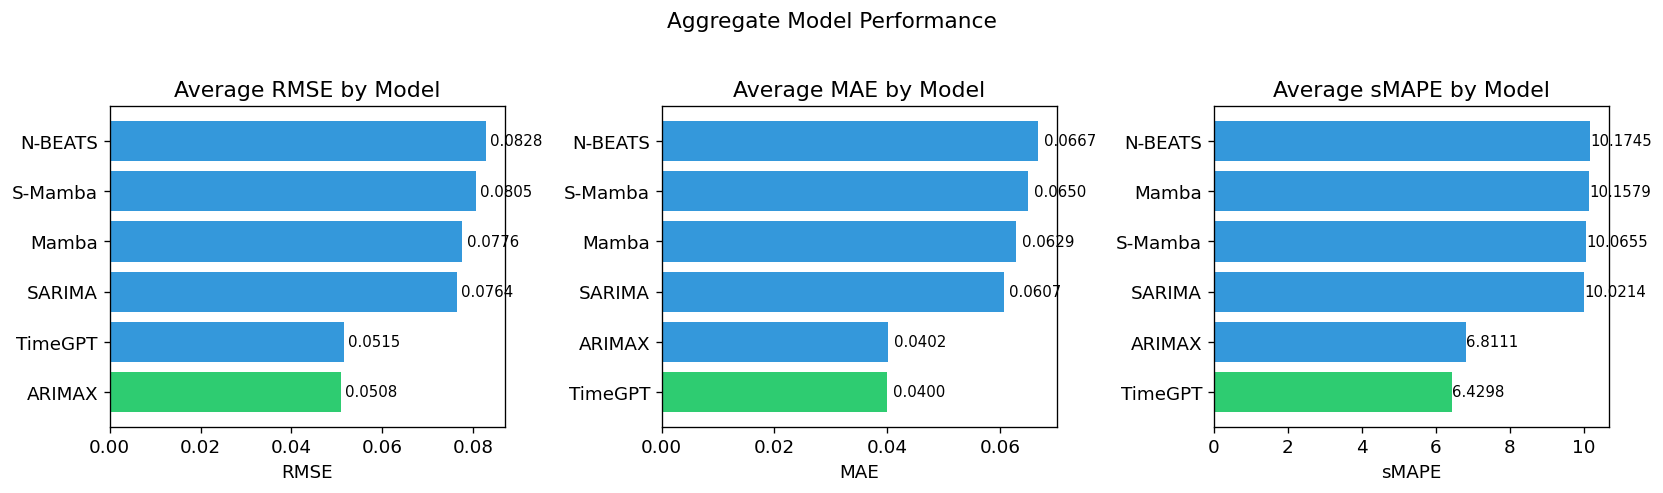

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'sMAPE']):
    sub = summary.sort_values(metric)
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(sub))]
    bars = ax.barh(sub['model'], sub[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'Average {metric} by Model')
    for bar, val in zip(bars, sub[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
plt.suptitle('Aggregate Model Performance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Per-Commodity Error Heatmap

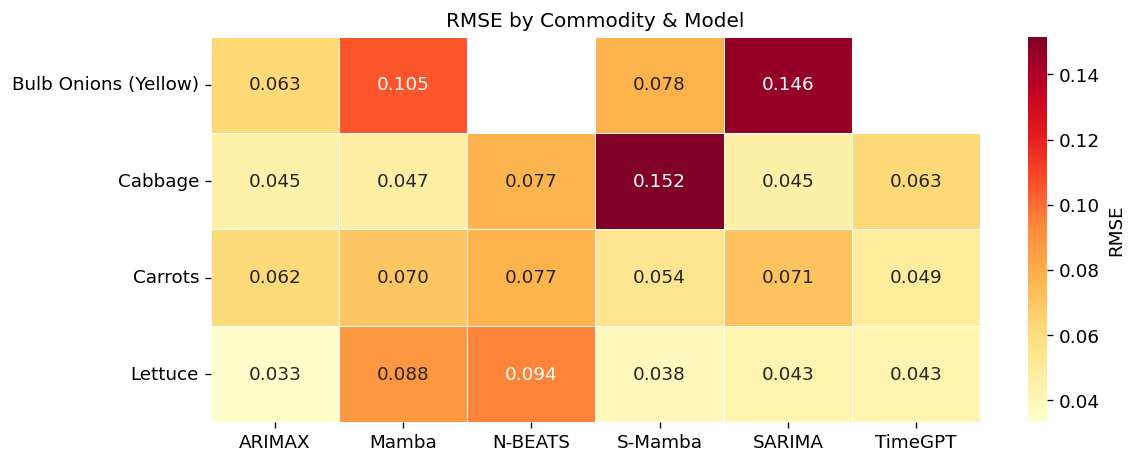

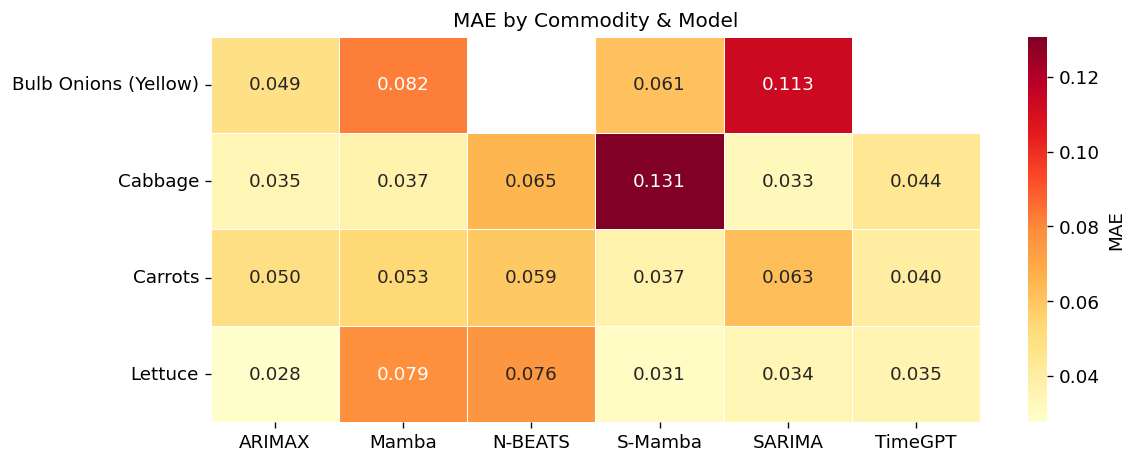

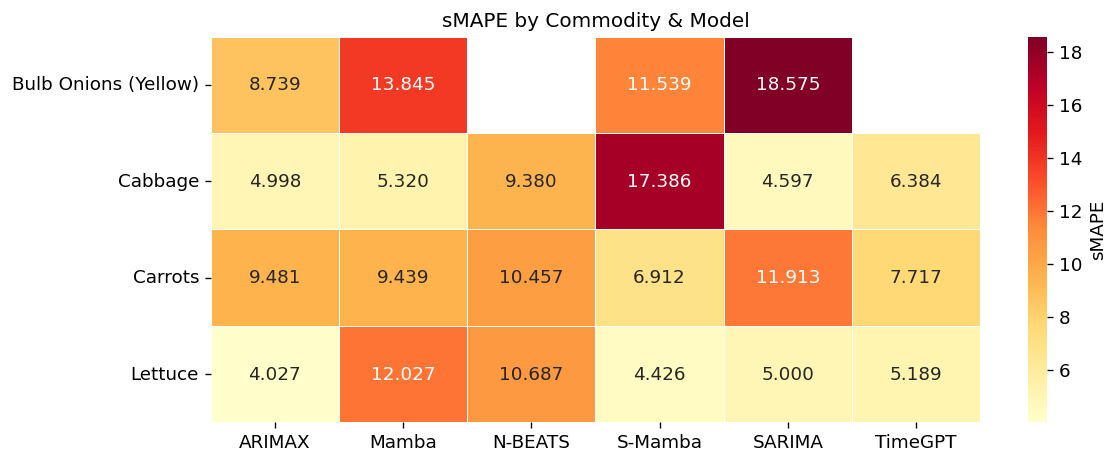

In [5]:
for metric in ['RMSE', 'MAE', 'sMAPE']:
    pivot = metrics.pivot(index='commodity', columns='model', values=metric)
    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot)*0.45)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.4, ax=ax, cbar_kws={'label': metric})
    ax.set_title(f'{metric} by Commodity & Model', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

## 4. Residual Distribution

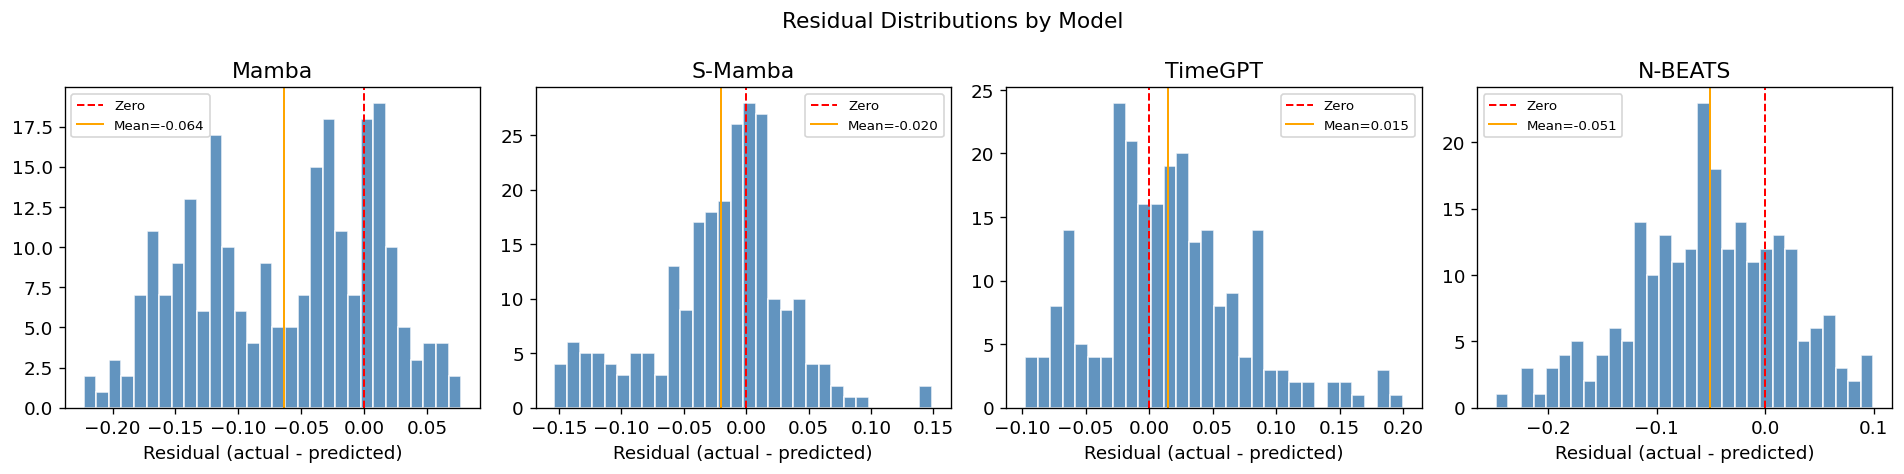

In [6]:
models = preds['model'].unique()
fig, axes = plt.subplots(1, len(models), figsize=(4*len(models), 4), sharey=False)

for ax, model in zip(axes, models):
    sub = preds[preds['model'] == model]['error'].dropna()
    ax.hist(sub, bins=30, edgecolor='white', color='steelblue', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero')
    ax.axvline(sub.mean(), color='orange', linestyle='-', linewidth=1.2,
               label=f'Mean={sub.mean():.3f}')
    ax.set_title(model)
    ax.set_xlabel('Residual (actual - predicted)')
    ax.legend(fontsize=8)

plt.suptitle('Residual Distributions by Model', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# Bias (mean error) and spread (std) summary
bias_df = preds.groupby('model')['error'].agg(
    bias='mean', std='std', skewness=lambda x: x.skew(), kurtosis=lambda x: x.kurt()
).round(4)
print('Residual statistics (bias = mean error, positive = under-prediction):')
display(bias_df)

Residual statistics (bias = mean error, positive = under-prediction):


,bias,std,skewness,kurtosis
model,,,,
Mamba,-0.0638,0.0723,-0.1671,-1.1197
N-BEATS,-0.0513,0.0700,-0.2618,-0.1962
S-Mamba,-0.0202,0.0526,-0.4511,0.6995
TimeGPT,0.0148,0.0576,0.5481,0.4693


## 5. Bias by Commodity

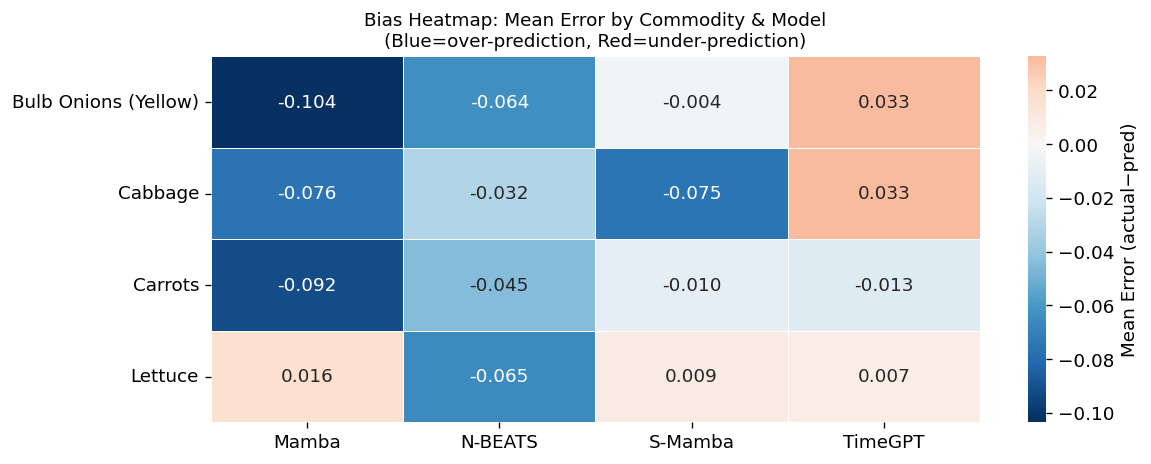

In [8]:
bias_comm = preds.groupby(['model', 'commodity'])['error'].mean().reset_index()
bias_comm.columns = ['model', 'commodity', 'mean_error']

pivot_bias = bias_comm.pivot(index='commodity', columns='model', values='mean_error')
fig, ax = plt.subplots(figsize=(10, max(4, len(pivot_bias)*0.45)))
sns.heatmap(pivot_bias, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Mean Error (actual−pred)'})
ax.set_title('Bias Heatmap: Mean Error by Commodity & Model\n(Blue=over-prediction, Red=under-prediction)', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Actual vs Predicted Plots

In [9]:
# Shared commodities across all models
common_commodities = (
    preds.groupby('commodity')['model'].nunique()
    .pipe(lambda s: s[s == s.max()].index.tolist())
)
print(f'Commodities present in all models: {common_commodities}')

Commodities present in all models: ['Bulb Onions (Yellow)', 'Cabbage', 'Carrots', 'Lettuce']


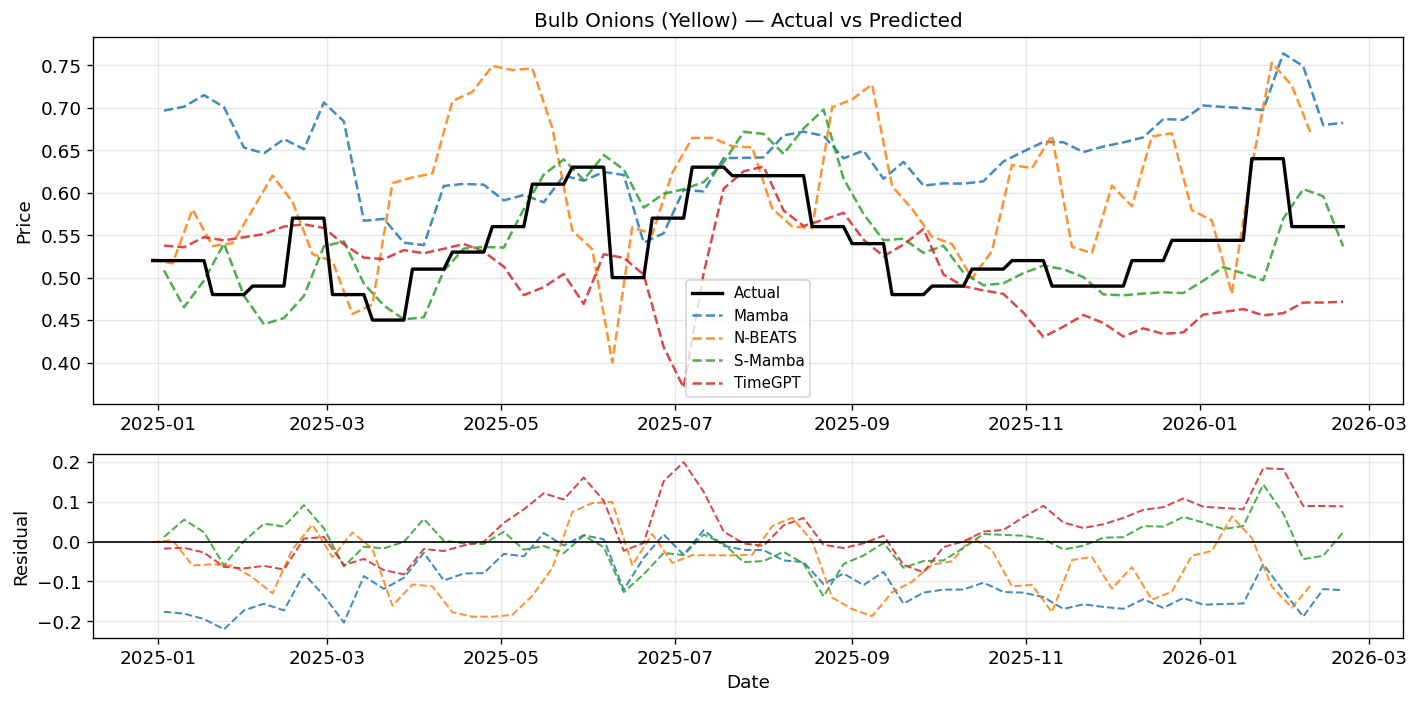

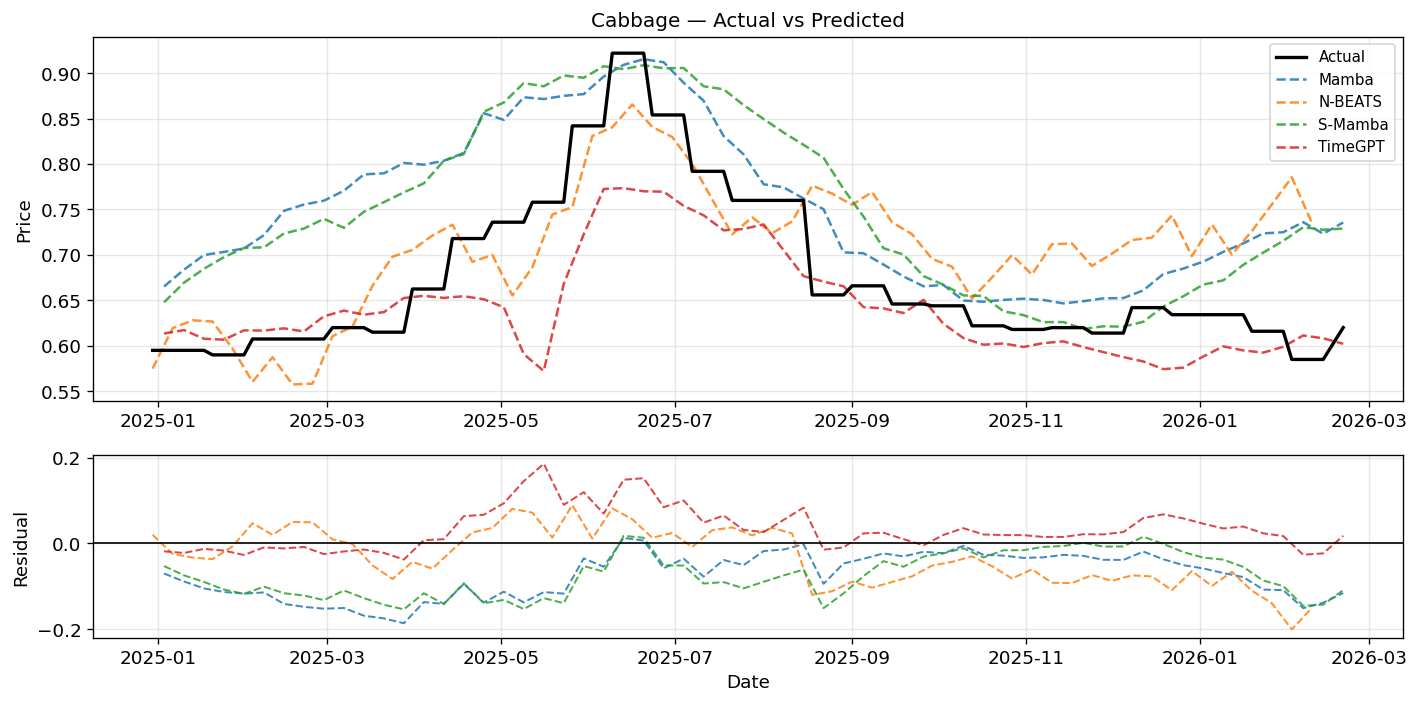

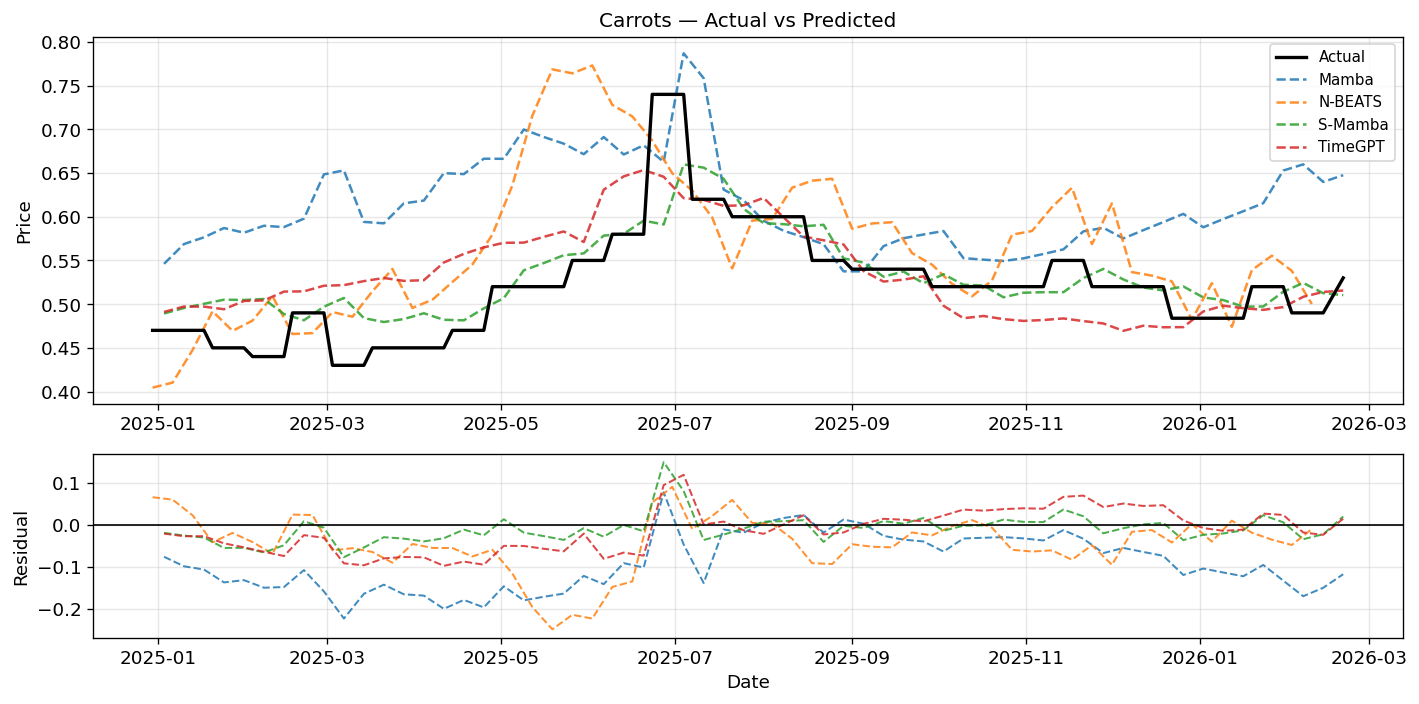

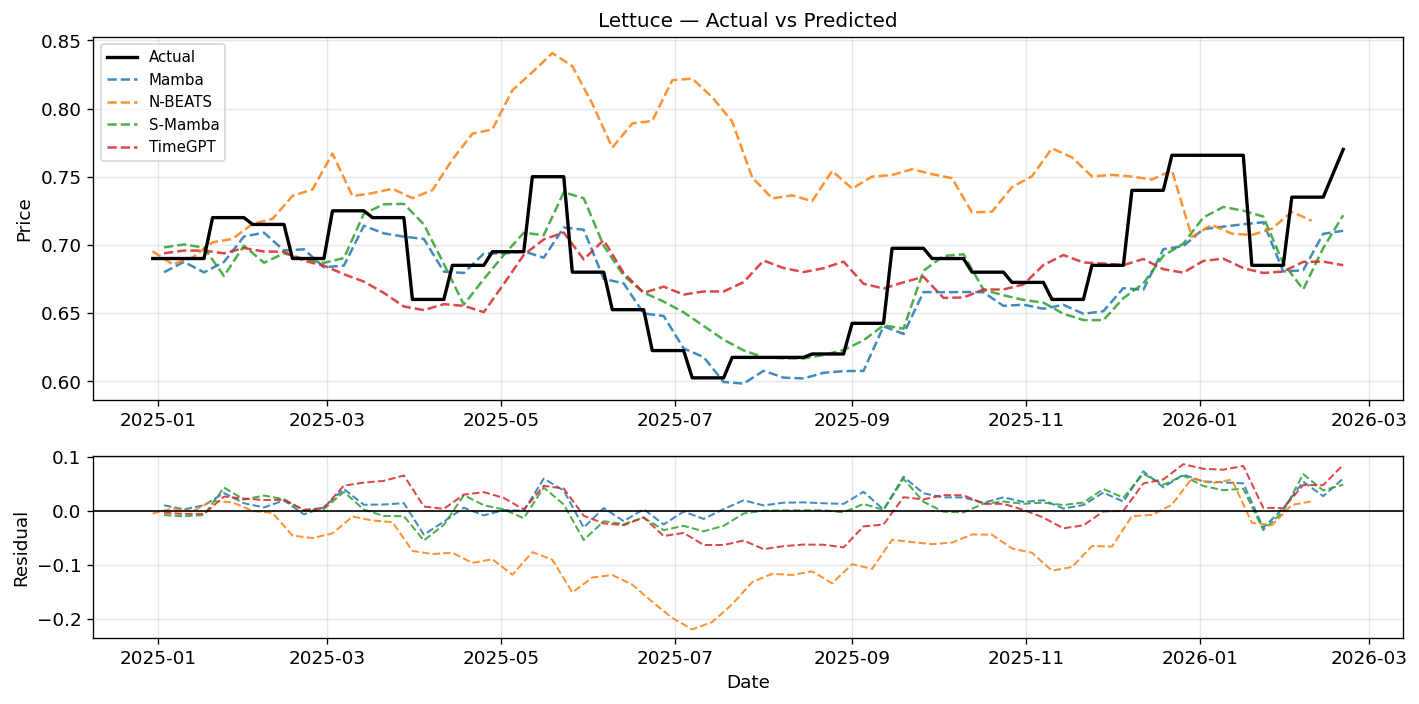

In [10]:
colors = plt.cm.tab10.colors

for commodity in common_commodities:
    sub = preds[preds['commodity'] == commodity].sort_values('date')
    actuals = sub.groupby('date')['actual'].first()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                    gridspec_kw={'height_ratios': [2, 1]})

    ax1.plot(actuals.index, actuals.values, 'k-', linewidth=2, label='Actual', zorder=5)
    for i, (model, grp) in enumerate(sub.groupby('model')):
        grp = grp.sort_values('date')
        ax1.plot(grp['date'], grp['predicted'], '--', color=colors[i],
                 linewidth=1.5, label=model, alpha=0.85)
    ax1.set_title(f'{commodity} — Actual vs Predicted', fontsize=12)
    ax1.set_ylabel('Price')
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    for i, (model, grp) in enumerate(sub.groupby('model')):
        grp = grp.sort_values('date')
        ax2.plot(grp['date'], grp['error'], '--', color=colors[i],
                 linewidth=1.2, label=model, alpha=0.85)
    ax2.axhline(0, color='black', linewidth=1.0)
    ax2.set_ylabel('Residual')
    ax2.set_xlabel('Date')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 7. Absolute Error Over Time (trend check)

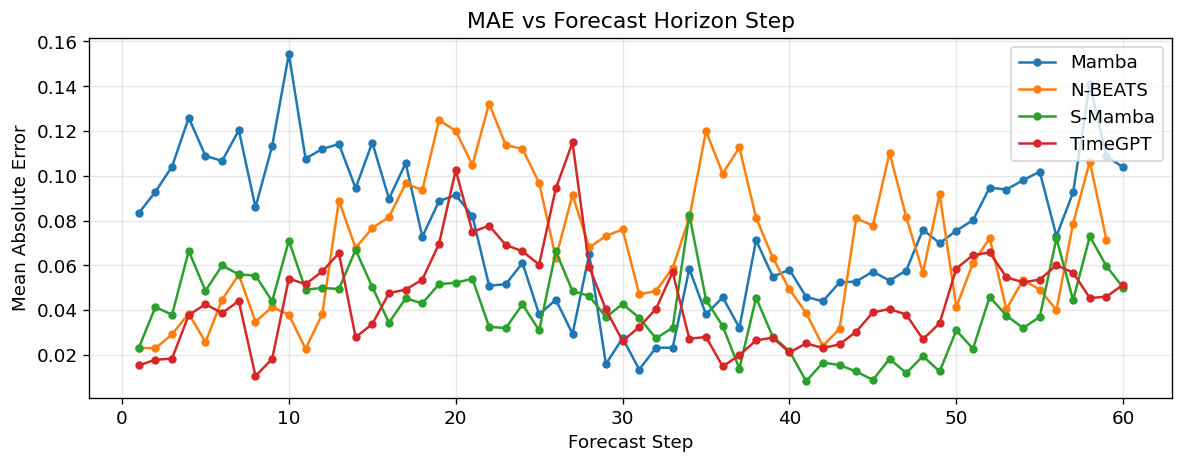

In [11]:
# Does error grow or shrink as the forecast horizon increases?
preds_sorted = preds.sort_values(['model', 'commodity', 'date'])
preds_sorted['step'] = preds_sorted.groupby(['model', 'commodity']).cumcount() + 1

horizon_err = preds_sorted.groupby(['model', 'step'])['abs_error'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
for i, (model, grp) in enumerate(horizon_err.groupby('model')):
    ax.plot(grp['step'], grp['abs_error'], marker='o', markersize=4,
            color=colors[i], label=model)
ax.set_xlabel('Forecast Step')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('MAE vs Forecast Horizon Step')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Worst & Best Predictions

In [12]:
print('=== 10 Worst Predictions (highest absolute error) ===')
display(
    preds.nlargest(10, 'abs_error')[['model','commodity','date','actual','predicted','error','abs_error']]
    .round(4).reset_index(drop=True)
)

print('\n=== 10 Best Predictions (lowest absolute error) ===')
display(
    preds.nsmallest(10, 'abs_error')[['model','commodity','date','actual','predicted','error','abs_error']]
    .round(4).reset_index(drop=True)
)

=== 10 Worst Predictions (highest absolute error) ===


,model,commodity,date,actual,predicted,error,abs_error
0,N-BEATS,Carrots,2025-05-19,0.5200,0.7686,-0.2486,0.2486
1,N-BEATS,Carrots,2025-06-02,0.5500,0.7731,-0.2231,0.2231
2,Mamba,Carrots,2025-03-07,0.4300,0.6530,-0.2230,0.2230
3,Mamba,Bulb Onions (Yellow),2025-01-24,0.4800,0.7006,-0.2206,0.2206
4,N-BEATS,Lettuce,2025-07-07,0.6025,0.8219,-0.2194,0.2194
5,N-BEATS,Carrots,2025-05-26,0.5500,0.7641,-0.2141,0.2141
6,N-BEATS,Lettuce,2025-07-14,0.6025,0.8083,-0.2058,0.2058
7,Mamba,Bulb Onions (Yellow),2025-03-07,0.4800,0.6838,-0.2038,0.2038
8,N-BEATS,Cabbage,2026-02-02,0.5850,0.7855,-0.2005,0.2005
9,Mamba,Carrots,2025-04-11,0.4500,0.6499,-0.1999,0.1999



=== 10 Best Predictions (lowest absolute error) ===


,model,commodity,date,actual,predicted,error,abs_error
0,S-Mamba,Lettuce,2025-08-01,0.6175,0.6175,0.0000,0.0000
1,TimeGPT,Lettuce,2025-12-05,0.6850,0.6852,-0.0002,0.0002
2,Mamba,Lettuce,2025-05-09,0.6950,0.6952,-0.0002,0.0002
3,TimeGPT,Bulb Onions (Yellow),2025-10-10,0.4900,0.4898,0.0002,0.0002
4,S-Mamba,Lettuce,2025-02-21,0.6900,0.6897,0.0003,0.0003
5,N-BEATS,Lettuce,2025-02-03,0.7150,0.7154,-0.0004,0.0004
6,S-Mamba,Carrots,2025-06-13,0.5800,0.5805,-0.0005,0.0005
7,TimeGPT,Bulb Onions (Yellow),2025-04-25,0.5300,0.5305,-0.0005,0.0005
8,S-Mamba,Lettuce,2025-08-08,0.6175,0.6169,0.0006,0.0006
9,TimeGPT,Carrots,2025-07-11,0.6200,0.6193,0.0007,0.0007


In [13]:
# Per-model worst commodity
print('Hardest commodity per model (highest avg MAE):')
display(
    preds.groupby(['model','commodity'])['abs_error'].mean()
    .reset_index()
    .sort_values('abs_error', ascending=False)
    .groupby('model').first()
    .rename(columns={'abs_error':'avg_MAE', 'commodity':'hardest_commodity'})
    .round(4)
)

Hardest commodity per model (highest avg MAE):


,hardest_commodity,avg_MAE
model,,
Mamba,Bulb Onions (Yellow),0.1065
N-BEATS,Bulb Onions (Yellow),0.0819
S-Mamba,Cabbage,0.0767
TimeGPT,Bulb Onions (Yellow),0.0610


## 9. Statistical Significance (Diebold-Mariano–style comparison)

In [14]:
from itertools import combinations

results = []
for m1, m2 in combinations(preds['model'].unique(), 2):
    df1 = preds[preds['model'] == m1].set_index(['commodity','date'])['abs_error']
    df2 = preds[preds['model'] == m2].set_index(['commodity','date'])['abs_error']
    common_idx = df1.index.intersection(df2.index)
    if len(common_idx) < 5:
        continue
    d = df1.loc[common_idx].values - df2.loc[common_idx].values
    t_stat, p_val = stats.ttest_1samp(d, 0)
    results.append({
        'Model A': m1, 'Model B': m2,
        'n_obs': len(d),
        'mean_diff (A-B)': d.mean(),
        't_stat': t_stat,
        'p_value': p_val,
        'significant (p<0.05)': p_val < 0.05
    })

dm = pd.DataFrame(results).sort_values('p_value')
display(dm.round(4))

,Model A,Model B,n_obs,mean_diff (A-B),t_stat,p_value,significant (p<0.05)
0,Mamba,S-Mamba,240,0.0353,9.3947,0.0000,True
1,Mamba,TimeGPT,240,0.0303,7.0737,0.0000,True
2,S-Mamba,TimeGPT,240,-0.0050,-1.5012,0.1346,False


## 10. Summary

Key takeaways from the error analysis:

| Finding | Detail |
|---|---|
| **Best overall** | Model with lowest avg RMSE / MAE (see Section 2) |
| **Bias** | Models with positive mean error systematically under-predict prices |
| **Hardest commodity** | Check Section 8 — typically high-volatility produce (e.g., Asparagus, Strawberries) |
| **Horizon drift** | See Section 7 — whether error compounds over the forecast window |
| **Statistical tests** | Section 9 shows which model differences are statistically significant |